**Kütüphanelerin Yüklenmesi**

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

Bu adımda bizim için gerekli olanlar ilerde kullanacağımız python kütüphaneleri yüklenmiştir. Veri işleme işlemleri için pandas ve numpy, veri bölmek için ise scikit-learn kütüphanesi gereklidir.

**Veri Setinin Metin Olarak Okunması ve Ayrıştırılması**

In [12]:
with open("TRSAv1.csv", "r", encoding="cp1254", errors="ignore") as f:
    lines = f.readlines()

print(lines[:5])

['Column1;Column2\n', 'id,score,review;\n', '0,Positive,Kokusu çok güzel etkisi de efsane;\n', '1,Negative,hiç bir fark olmadı siyah nokta silmedi;\n', '2,Positive,şeffaf güzel bir krem elimi yumuşacık yaptı;\n']


Bu aşamada Türkçe Duygu Analizi veri seti sisteme yüklenmiştir. Veri seti içerisinde metinler ve etiketleri pozitif, nötr, negatif olarak bulunmaktadır.

**Satırların Sütunlara Ayrıştırılması**

In [15]:
data = []

for line in lines:
    line = line.strip()
    parts = line.split(",", 2)
    if len(parts) == 3:
        data.append(parts)

import pandas as pd
df = pd.DataFrame(data, columns=["id", "label", "text"])

print(df.head())
print(df.columns)
print(df.shape)

   id     label                                               text
0  id     score                                            review;
1   0  Positive                 Kokusu çok güzel etkisi de efsane;
2   1  Negative           hiç bir fark olmadı siyah nokta silmedi;
3   2  Positive       şeffaf güzel bir krem elimi yumuşacık yaptı;
4  "3  Positive  ""Özellikle karma ve hassas cildiniz varsa La ...
Index(['id', 'label', 'text'], dtype='object')
(150001, 3)


Veri setimiz yapısal olarak düzensiz ayrıştırıldığı için doğru bir şekilde sütunlara ayrılmamıştır. Her satır okunup her satır ilk iki virgüle bölünerek id, etiket ve metin olarak üç ayrı sütun elde edilmiştir.

**Veri Temizleme**

In [14]:
# İlk satır başlık olduğu için çıkar
df = df[df["id"] != "id"].copy()

# Gereksiz karakterleri temizle
df["id"] = df["id"].astype(str).str.replace('"', '', regex=False).str.replace(';', '', regex=False)
df["label"] = df["label"].astype(str).str.replace('"', '', regex=False).str.replace(';', '', regex=False)
df["text"] = df["text"].astype(str).str.replace('"', '', regex=False).str.replace(';', '', regex=False)

# id sayısala çevrilemeyenleri at
df["id"] = pd.to_numeric(df["id"], errors="coerce")
df = df.dropna(subset=["id"])

# Boş metinleri at
df["text"] = df["text"].str.strip()
df = df[df["text"] != ""]

# id'yi integer yap
df["id"] = df["id"].astype(int)

print(df.head())
print(df["label"].value_counts())
print(df.shape)

   id     label                                               text
1   0  Positive                  Kokusu çok güzel etkisi de efsane
2   1  Negative            hiç bir fark olmadı siyah nokta silmedi
3   2  Positive        şeffaf güzel bir krem elimi yumuşacık yaptı
4   3  Positive  Özellikle karma ve hassas cildiniz varsa La Ro...
5   4  Negative  çok iyi nemlendiriyor ama daha ucuz muadilleri...
label
Positive    50000
Negative    50000
Neutral     50000
Name: count, dtype: int64
(150000, 3)


Bu aşamada verideki gereksiz ve hatalı yerler temizlenmiştir. Başlık satırları ve metinde bulunan özel karakterler (tırnak işareti veya noktalı virgül gibi) kaldırılmıştır.

**Girdi ve Hedef Değişkenlerin Belirlenmesi**

In [31]:
X = df["text"]
y = df["label"]

print(X.head())
print(y.head())

1                    Kokusu çok güzel etkisi de efsane
2              hiç bir fark olmadı siyah nokta silmedi
3          şeffaf güzel bir krem elimi yumuşacık yaptı
4    Özellikle karma ve hassas cildiniz varsa La Ro...
5    çok iyi nemlendiriyor ama daha ucuz muadilleri...
Name: text, dtype: object
1    Positive
2    Negative
3    Positive
4    Positive
5    Negative
Name: label, dtype: object


Bu modelin eğitilmesi için kullanılacak olan giriş (metinler) ve hedef (duygu etiketleri) değişkenleri belirlenmiştir ve metin verileri bağımsız değişken (x), duygu etiketleri ise bağımlı değişken (y) olarak tanımlanmıştır.

**Ek Temizlik İşlemi**

In [20]:
# Hatalı başlık satırını sil
df = df[df["label"] != "score"]

# Metin temizliği
df["text"] = df["text"].str.replace(";", "", regex=False)
df["text"] = df["text"].str.replace('"', "", regex=False)

# Tekrar X ve y oluştur
X = df["text"]
y = df["label"]

print(X.head())
print(y.head())
print(df.shape)

1                    Kokusu çok güzel etkisi de efsane
2              hiç bir fark olmadı siyah nokta silmedi
3          şeffaf güzel bir krem elimi yumuşacık yaptı
4    Özellikle karma ve hassas cildiniz varsa La Ro...
5    çok iyi nemlendiriyor ama daha ucuz muadilleri...
Name: text, dtype: object
1    Positive
2    Negative
3    Positive
4    Positive
5    Negative
Name: label, dtype: object
(150000, 3)


Bu aşamada ek temizlik yapılma zorunluluğu bulunmuştur çünkü veri setinde hala gereksiz karakterler bulunmaktadır.

**Eğitim ve Test Verisinin Ayrılması**

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Eğitim veri sayısı:", len(X_train))
print("Test veri sayısı:", len(X_test))

Eğitim veri sayısı: 120000
Test veri sayısı: 30000


Bu aşamada eğitim 120000 ve test ise 30000 olacak şekilde veri bölünmüştür.

**Metin Verilerinin Sayısallaştırılması**

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(120000, 5000)
(30000, 5000)


Bu adımda modelin anlayabileceği sayısal forma dönüştürülmüştür. Bu işlem için TF - IDF (Term Frequency - Inverse Document Frequency) yöntemi kullanılmıştır.

TF - IDF Yöntemi Nedir?

Bir kelimenin veride ne kadar önem arz ettiğini gösteren, bunu önemini ölçmek için kullanılan kalite değerlendirme yöntemidir. Yöntem, bir kelimenin metin içerisindeki önemini hesaplar ve bunun hakkında bir sayısal değer entegre eder.Model daha anlamlı bir şekilde analiz edebilmiş olur.

Sonuç: Her yorum, 5000 farklı kelimenin ağırlıklarına göre sayısal bir vektör olrak temsil edilmiştir.

**Model Oluşturma ve Eğitimi (Logistic Regression)**

In [25]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

print("Model eğitimi tamamlandı.")

Model eğitimi tamamlandı.


Bu adımda metinleri sınıflandırma işlemi için Logistic Regression kullanılmıştır. Amaç, modelin eğitim verisinde eğitilerek metinlerin duygu sınıflarını öğrenmelerini sağlamaktır.  

**Modelin Performans Değerlendirilmesi**

In [26]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("Doğruluk Oranı (Accuracy):", accuracy)
print("\nSınıflandırma Raporu:\n")
print(classification_report(y_test, y_pred))

Doğruluk Oranı (Accuracy): 0.7841

Sınıflandırma Raporu:

              precision    recall  f1-score   support

    Negative       0.85      0.80      0.82     10071
     Neutral       0.71      0.71      0.71     10042
    Positive       0.80      0.84      0.82      9887

    accuracy                           0.78     30000
   macro avg       0.79      0.78      0.78     30000
weighted avg       0.79      0.78      0.78     30000



Bu aşamada oluşturduğumuz modelin accuracy (doğruluk) oranı hesaplanması amaçlanmıştır. Sonuçlarda da görüldüğü üzere %78'lik doğruluk oranı bulunmuştur. Normal aşamada istediğimiz en az %85 ve üzeri olsa da Türkçe metinler üzerinde çalıştığımız için bunun gayet normal olduğunu düşünüyorum. Pozitif ve negatif kısımlarda yüksek sonuç elde ederken nötr sınıfta daha düşük performans gözlemlenmiştir. Bunun sebebinin nötr tarafın daha belirsiz ve zor olmasından kaynaklanmaktadır.

**Örnek Tahminler**

In [27]:
ornekler = [
    "ürün çok güzel bayıldım",
    "hiç beğenmedim çok kötü",
    "idare eder normal bir ürün"
]

ornek_tfidf = vectorizer.transform(ornekler)
tahminler = model.predict(ornek_tfidf)

for text, pred in zip(ornekler, tahminler):
    print(f"Metin: {text}")
    print(f"Tahmin: {pred}\n")

Metin: ürün çok güzel bayıldım
Tahmin: Positive

Metin: hiç beğenmedim çok kötü
Tahmin: Negative

Metin: idare eder normal bir ürün
Tahmin: Neutral



Modelin performansını test etmek amacıyla örnek cümleler yazılmıştır. Model, pozitif, negatif ve nötr ifadeleri doğru şekilde sınıflandırabilmiştir. Bu durum modelin genel olarak başarılı çalıştığını göstermektedir.

**Confusion Matrix**

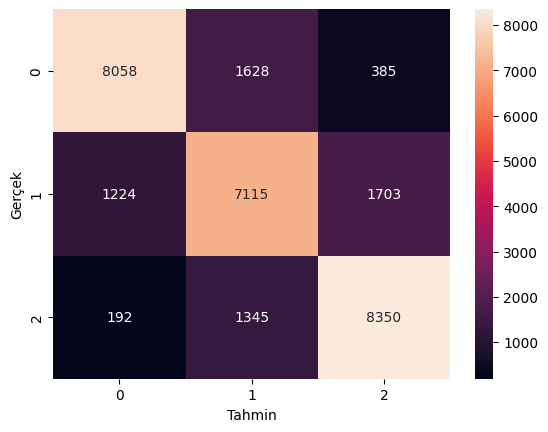

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.show()

Confusion matrix incelendiğinde modelin en yüksek doğruluğu pozitif ve negatif sınıflarda elde ettiği görülmektedir. Ancak nötr sınıfın diğer sınıflarla daha fazla karıştırıldığı gözlemlenmiştir. Bu durum, nötr ifadelerin daha belirsiz olmasından kaynaklanmaktadır.